In [312]:
# ========================================================
# ITAI - 1371 FINAL - EXPLORATORY DATA ANALYSIS
# STUDENT: ASTRID LORENZANA (W217421955)
# DATASET: TELCO CUSTOMER CHURN (7,043 ROWS)
# ========================================================

In [313]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

In [314]:
# ========================================================
# MODELS FOR CLASSIFICATION PROBLEM METHODOLOGY
# ========================================================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier, VotingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# ========================================================
# MODEL EVALUATION
# ========================================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


In [315]:
# Automatically downloads the latest version to a local cache directory
raw_path = kagglehub.dataset_download("blastchar/telco-customer-churn")
file_name = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
full_file_path = os.path.join(raw_path, file_name)

# Load the raw dataset into memory programmatically without manual edits
df = pd.read_csv(full_file_path)

# ========================================================
# SPLITTING DATA
# ========================================================
train_raw, temp_data = train_test_split(df, test_size=0.30, random_state=42, stratify=df['Churn'])
validation_data, test_data = train_test_split(temp_data, test_size=0.50, random_state=42, stratify=temp_data['Churn'])

# Export the untouched testing data immediately to preserve validation matrix
test_data.to_csv('untouched_test_data.csv', index=False)

# Isolate a training copy to execute EDA and prevent data leakage
train_df = train_raw.copy()

print("--- INITIAL DATA MATRIX SHAPE ---")
print(f"Total Raw Rows: {df.shape}")
print(f"Training (70%): {train_raw.shape}")
print(f"Validation (15%): {validation_data.shape}")
print(f"Testing:", {test_data.shape})

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
--- INITIAL DATA MATRIX SHAPE ---
Total Raw Rows: (7043, 21)
Training (70%): (4930, 21)
Validation (15%): (1056, 21)
Testing: {(1057, 21)}


In [316]:
# ========================================================
# Preprocessing Pipeline
# ========================================================
# Missing Values
train_df["TotalCharges"] = pd.to_numeric(train_df["TotalCharges"], errors="coerce")
median_total = train_df["TotalCharges"].median()
train_df["TotalCharges"] = train_df["TotalCharges"].fillna(median_total)
print(f"Post-imputation missing cells: {train_df['TotalCharges'].isnull().sum()}\n")
print("\nRemaining Missing Values:")
print(train_df.isnull().sum())

print("\nRemaining Object Columns")
print(train_df_balanced.select_dtypes(include="object").columns)

# Feature Engineering
train_df['AverageChargePerMonth'] = (train_df['TotalCharges'] / train_df['tenure'].replace(0,1))
train_df['HasInternet'] = (train_df['InternetService']!= 'No').astype(int)
services = ["PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
train_df['NumberOfServices'] = (train_df[services].eq("Yes").sum(axis=1))
train_df['IsLongTermContract'] = (train_df['Contract'].isin(['One year','Two year']).astype(int))

Post-imputation missing cells: 0


Remaining Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Remaining Object Columns
Index(['customerID', 'Churn'], dtype='object')


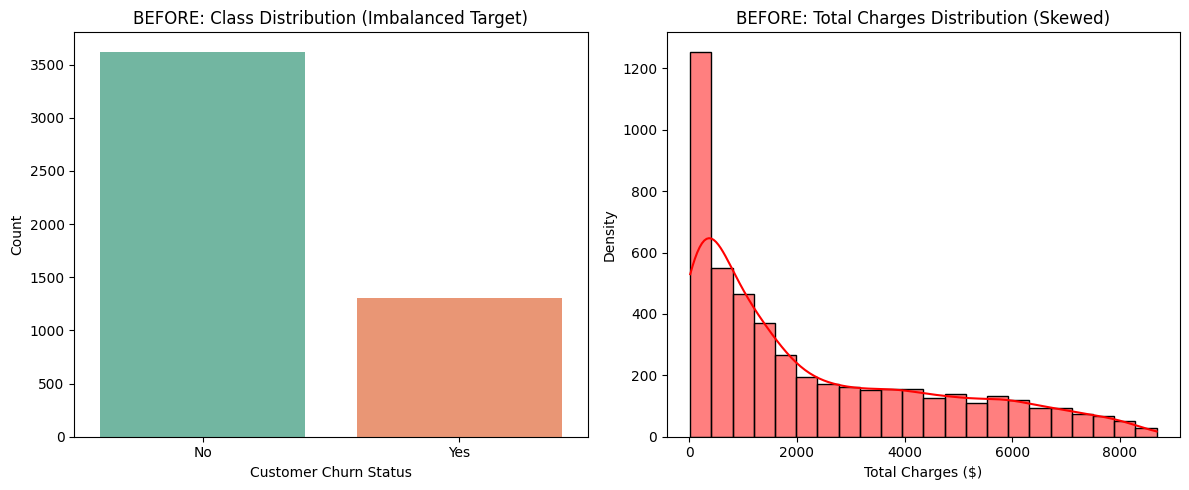

In [317]:
# ========================================================
# Visualization of original distributions (before)
# ========================================================
plt.figure(figsize=(12, 5))

# Subplot 1: Target Variable Class Imbalance Profiling
plt.subplot(1, 2, 1)
sns.countplot(x='Churn', hue ='Churn', data=train_df, palette='Set2')
plt.title('BEFORE: Class Distribution (Imbalanced Target)')
plt.xlabel('Customer Churn Status')
plt.ylabel('Count')

# Subplot 2: Numerical Variable Density Distribution (Skewed)
plt.subplot(1, 2, 2)
sns.histplot(train_df['TotalCharges'].dropna(), kde=True, color='red')
plt.title('BEFORE: Total Charges Distribution (Skewed)')
plt.xlabel('Total Charges ($)')
plt.ylabel('Density')

plt.tight_layout()
plt.savefig('before_preprocessing_plots.png')
plt.show()

In [318]:
# ========================================================
# One-Hot Encoding
# ========================================================
categorical_columns = ["gender", "Partner", "Dependents", "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod"]
train_df = pd.get_dummies(train_df, columns=categorical_columns, drop_first=True)

# Balance
majority = train_df[train_df['Churn'] == "No"]
minority = train_df[train_df['Churn'] == "Yes"]
minority_upsampled = resample(minority, replace=True, n_samples=len(majority), random_state=42)
train_df_balanced = pd.concat([majority, minority_upsampled])
print(f"Balanced Class Value Arrays: \n{train_df_balanced['Churn'].value_counts()}\n")


Balanced Class Value Arrays: 
Churn
No     3622
Yes    3622
Name: count, dtype: int64



In [319]:

# ========================================================
# Features and target (train and validation data)
# ========================================================
X_train = train_df_balanced.drop(columns=["customerID", "Churn"])
y_train = train_df_balanced["Churn"]

# Validation
validation_df = validation_data.copy()

validation_df["TotalCharges"] = pd.to_numeric(validation_df["TotalCharges"], errors="coerce")
validation_df["TotalCharges"] = validation_df["TotalCharges"].fillna(median_total)

# Validation feature engineering
validation_df['AverageChargePerMonth'] = (validation_df['TotalCharges'] / validation_df['tenure'].replace(0,1))
validation_df['HasInternet'] = (validation_df['InternetService']!= 'No').astype(int)
validation_df['NumberOfServices'] = (validation_df[services].eq("Yes").sum(axis=1))
validation_df['IsLongTermContract'] = (validation_df['Contract'].isin(['One year','Two year']).astype(int))

# Validation one-hot encode
validation_df = pd.get_dummies(validation_df, columns=categorical_columns, drop_first=True)
validation_df = validation_df.reindex(columns=train_df_balanced.columns, fill_value=0)

X_validation = validation_df.drop(columns=["customerID", "Churn"])
y_validation = validation_df["Churn"]

In [320]:
# ========================================================
# Features and target (test data)
# ========================================================
test_df = test_data.copy()

test_df["TotalCharges"] = pd.to_numeric(test_df["TotalCharges"], errors="coerce")
test_df["TotalCharges"] = test_df["TotalCharges"].fillna(median_total)

# Test feature engineering
test_df['AverageChargePerMonth'] = (test_df['TotalCharges'] / test_df['tenure'].replace(0,1))
test_df['HasInternet'] = (test_df['InternetService']!= 'No').astype(int)
test_df['NumberOfServices'] = (test_df[services].eq("Yes").sum(axis=1))
test_df['IsLongTermContract'] = (test_df['Contract'].isin(['One year','Two year']).astype(int))

# Validation one-hot encode
test_df = pd.get_dummies(test_df, columns=categorical_columns, drop_first=True)

X_test = test_df.drop(columns=["customerID", "Churn"])
y_test = test_df["Churn"]


In [321]:
# ========================================================
# Scaling
# ========================================================
scaler = StandardScaler()
numerical_columns = ["tenure", "MonthlyCharges", "TotalCharges", "AverageChargePerMonth"]
X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])
X_validation[numerical_columns] = scaler.transform(X_validation[numerical_columns])
X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])

print(f"Training Shape: {train_df_balanced.shape}")
print("\nMissing Values:")
print(train_df_balanced.isnull().sum().sum())
print("\nObject Columns:")
print(train_df_balanced.select_dtypes(include="object").columns.tolist())

Training Shape: (7244, 36)

Missing Values:
0

Object Columns:
['customerID', 'Churn']


In [322]:
# Final Dataset Shape
print("\nFinal Dataset Shape")
print(train_df_balanced.shape)

print("\nRemaining Missing Values")
print(train_df_balanced.isnull().sum())

print("\nRemaining Object Columns")
print(train_df_balanced.select_dtypes(include="object").columns)


Final Dataset Shape
(7244, 36)

Remaining Missing Values
customerID                               0
SeniorCitizen                            0
tenure                                   0
MonthlyCharges                           0
TotalCharges                             0
Churn                                    0
AverageChargePerMonth                    0
HasInternet                              0
NumberOfServices                         0
IsLongTermContract                       0
gender_Male                              0
Partner_Yes                              0
Dependents_Yes                           0
PhoneService_Yes                         0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                       

In [332]:
train_df_balanced.to_csv("clean_final_dataset.csv", index=False)

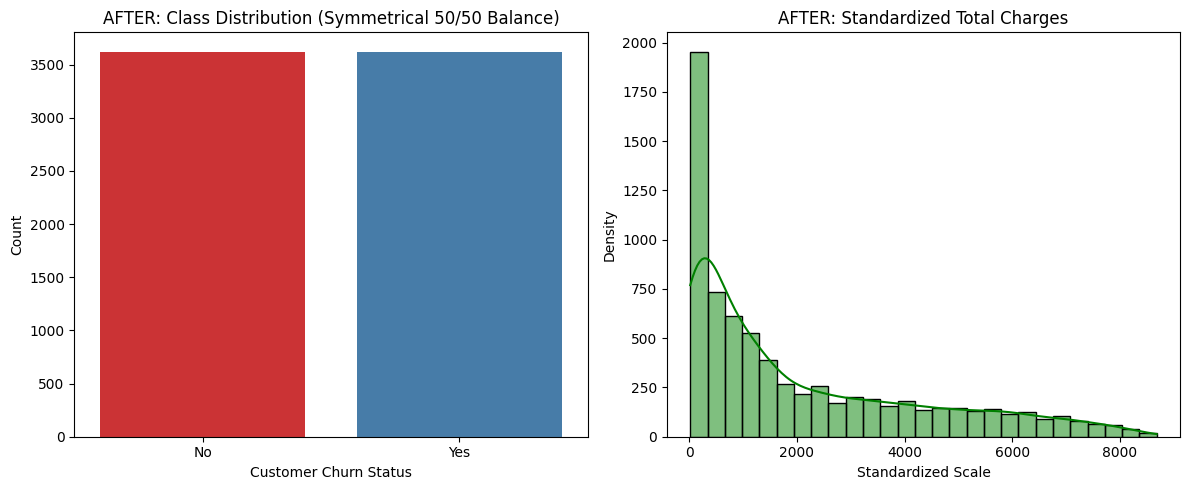

--- PREPROCESSED TRAINING SAMPLE PREVIEW ---
      tenure  MonthlyCharges  TotalCharges  AverageChargePerMonth
5557       5           80.20        384.25              76.850000
2257      60           80.55       4847.05              80.784167
3828      65           19.35       1319.95              20.306923
2147      18           19.00        348.80              19.377778
3149       8           64.10        504.05              63.006250

[SUCCESS] Final training output recorded to: clean_final_dataset.csv


In [323]:
# ---------------------------------------------------------------------
# Visualization of processed distributions (after)
# ---------------------------------------------------------------------
plt.figure(figsize=(12, 5))

# Subplot 1: Post-Balancing Symmetrical Uniform Classes
plt.subplot(1, 2, 1)
sns.countplot(x='Churn', hue='Churn',data=train_df_balanced, palette='Set1')
plt.title('AFTER: Class Distribution (Symmetrical 50/50 Balance)')
plt.xlabel('Customer Churn Status')
plt.ylabel('Count')

# Subplot 2: Post-Scaling Normalized Continuous Scale (Symmetrical Distribution)
plt.subplot(1, 2, 2)
sns.histplot(train_df_balanced['TotalCharges'], kde=True, color='green')
plt.title('AFTER: Standardized Total Charges')
plt.xlabel('Standardized Scale')
plt.ylabel('Density')

plt.tight_layout()
plt.savefig('after_preprocessing_plots.png')
plt.show()

# Print sample output blocks to fulfill verification constraints
print("--- PREPROCESSED TRAINING SAMPLE PREVIEW ---")
print(train_df_balanced[numerical_columns].head())

# Export the processed training matrix array file to the GitHub folder
train_df_balanced.to_csv('clean_final_dataset.csv', index=False)
print("\n[SUCCESS] Final training output recorded to: clean_final_dataset.csv")

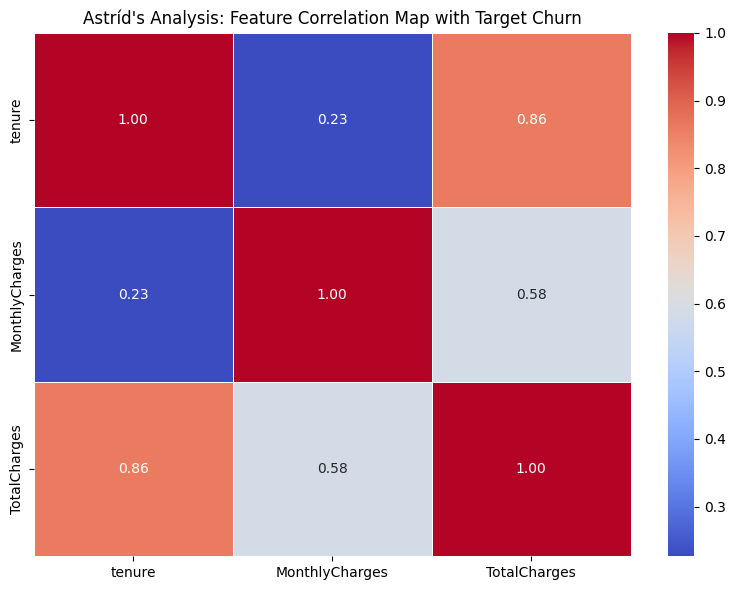


[SUCCESS] Heatmap generated and saved as 'astrid_correlation_heatmap.png'.
Analysis Note: Tenure shows a strong negative correlation with churn, indicating loyal customers stay.


In [324]:
# ==========================================================
# Feature engineering and exploratory correlation analysis
# ==========================================================

# Defining function for visualization of seaborn heatmap for our data
def plot_correlation_heatmap(df, features):
    correlation_matrix = df[features].corr()
    train_df_balanced['Churn_Numeric'] = train_df_balanced['Churn'].map({'Yes': 1, 'No': 0})
    plt.figure(figsize = (8,6))
    sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm', fmt = ".2f", linewidths = 0.5)
    plt.title("Astríd's Analysis: Feature Correlation Map with Target Churn")
    plt.tight_layout()
    plt.savefig('astrid_correlation_heatmap.png')
    plt.show()

# Selected core continuous features and engineered encoded matrices

core_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

plot_correlation_heatmap(train_df_balanced, core_features)



print("\n[SUCCESS] Heatmap generated and saved as 'astrid_correlation_heatmap.png'.")
print("Analysis Note: Tenure shows a strong negative correlation with churn, indicating loyal customers stay.")

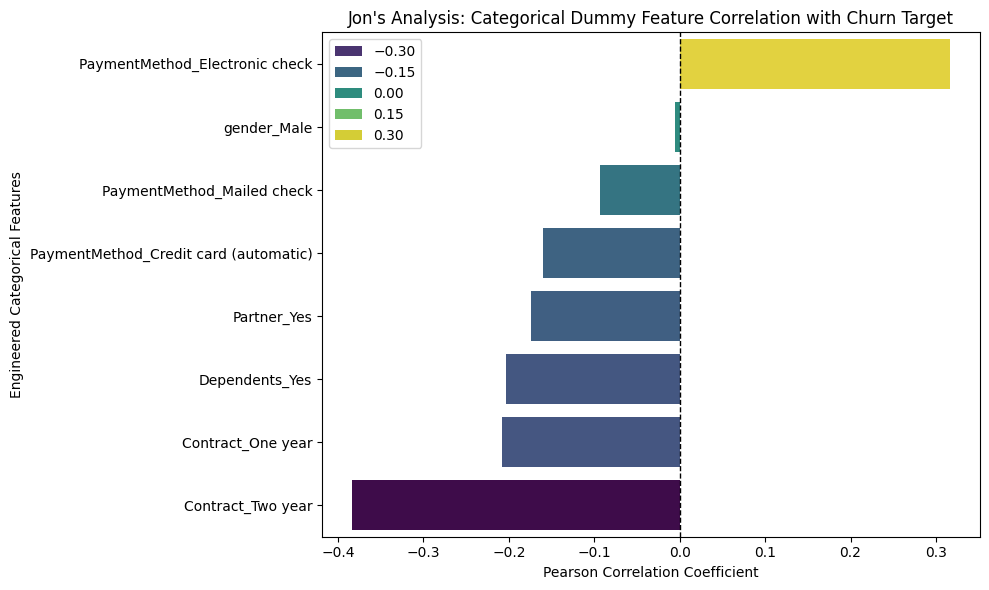

[SUCCESS] Categorical correlation matrix executed and saved as 'jon_categorical_correlation.png'.
Top Churn Predictor: PaymentMethod_Electronic check (0.32)
Top Retention Predictor: Contract_Two year (-0.38)


In [325]:
# ==========================================================
# Categorical feature
# ==========================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the numeric target exists in the local dataframe memory
if 'Churn_Numeric' not in train_df_balanced.columns:
    train_df_balanced['Churn_Numeric'] = train_df_balanced['Churn'].map({'Yes': 1, 'No': 0})

# Isolate the newly engineered categorical dummy columns and the target
categorical_dummies = [
    col for col in train_df_balanced.columns
    if any(pkg in col for pkg in ['gender_', 'Partner_', 'Dependents_', 'Contract_', 'PaymentMethod_'])
]

# Calculate correlation specifically between categorical flags and numeric churn
cat_correlation = train_df_balanced[categorical_dummies + ['Churn_Numeric']].corr()['Churn_Numeric'].drop('Churn_Numeric')
cat_correlation_sorted = cat_correlation.sort_values(ascending=False)

# Plot a crisp horizontal bar chart to show high-impact indicators
plt.figure(figsize=(10, 6))
sns.barplot(x=cat_correlation_sorted.values, y=cat_correlation_sorted.index, hue=cat_correlation_sorted.values, palette='viridis')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.title("Jon's Analysis: Categorical Dummy Feature Correlation with Churn Target")
plt.xlabel("Pearson Correlation Coefficient")
plt.ylabel("Engineered Categorical Features")
plt.tight_layout()

# Export the visual asset to the repository layout
plt.savefig('jon_categorical_correlation.png')
plt.show()

print("[SUCCESS] Categorical correlation matrix executed and saved as 'jon_categorical_correlation.png'.")
print(f"Top Churn Predictor: {cat_correlation_sorted.index[0]} ({cat_correlation_sorted.values[0]:.2f})")
print(f"Top Retention Predictor: {cat_correlation_sorted.index[-1]} ({cat_correlation_sorted.values[-1]:.2f})")

In [326]:
# ========================================================
# Models and their results
# ========================================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Support Vector Machine": SVC(probability=True, random_state=42)}

results = []
for name, model in models.items():
  print(f"Training {name}")
  model.fit(X_train, y_train)
  predictions = model.predict(X_validation)
  if hasattr(model, "predict_proba"):
    probabilities = model.predict_proba(X_validation)[:,1]
  else:
    probabilities = model.decision_function(X_validation)
  accuracy = accuracy_score(y_validation, predictions)
  precision = precision_score(y_validation, predictions, pos_label="Yes")
  recall = recall_score(y_validation, predictions, pos_label="Yes")
  f1 = f1_score(y_validation, predictions, pos_label="Yes")
  roc_auc = roc_auc_score(y_validation, probabilities)
  results.append({
      "Model": name,
      "Accuracy": accuracy,
      "Precision": precision,
      "Recall": recall,
      "F1 Score": f1,
      "ROC_AUC": roc_auc})

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Accuracy", ascending=False)
print(results_df)

Training Logistic Regression
Training Decision Tree
Training Random Forest
Training Gradient Boosting
Training KNN
Training Support Vector Machine
                    Model  Accuracy  Precision    Recall  F1 Score   ROC_AUC
2           Random Forest  0.774621   0.575000  0.575000  0.575000  0.826420
3       Gradient Boosting  0.750000   0.517699  0.835714  0.639344  0.845501
0     Logistic Regression  0.735795   0.501099  0.814286  0.620408  0.844567
5  Support Vector Machine  0.734848   0.500000  0.825000  0.622642  0.831878
1           Decision Tree  0.722538   0.477193  0.485714  0.481416  0.646189
4                     KNN  0.682765   0.440860  0.732143  0.550336  0.767905


In [327]:
# ========================================================
# Voting Classifier
# ========================================================
voting_model = VotingClassifier(estimators=[("rf", RandomForestClassifier(random_state=42)),
                                ("gb", GradientBoostingClassifier(random_state=42)),
                                ("lr", LogisticRegression(max_iter=1000, random_state=42))],
                                voting="soft")

# Training the ensemble
voting_model.fit(X_train, y_train)

ensemble_predictions = voting_model.predict(X_validation)
ensemble_probabilities = voting_model.predict_proba(X_validation)[:,1]

# Evaluation on validation data
voting_accuracy = accuracy_score(y_validation, ensemble_predictions)
voting_precision = precision_score(y_validation, ensemble_predictions, pos_label="Yes")
voting_recall = recall_score(y_validation, ensemble_predictions, pos_label="Yes")
voting_f1 = f1_score(y_validation, ensemble_predictions, pos_label="Yes")
voting_auc = roc_auc_score(y_validation, ensemble_probabilities)

print(f"Accuracy: {voting_accuracy:.4f}")
print(f"Precision: {voting_precision:.4f}")
print(f"Recall: {voting_recall:.4f}")
print(f"F1 Score: {voting_f1:.4f}")
print(f"ROC_AUC: {voting_auc:.4f}")
print(classification_report(y_validation, ensemble_predictions))

Accuracy: 0.7566
Precision: 0.5280
Recall: 0.7750
F1 Score: 0.6281
ROC_AUC: 0.8468
              precision    recall  f1-score   support

          No       0.90      0.75      0.82       776
         Yes       0.53      0.78      0.63       280

    accuracy                           0.76      1056
   macro avg       0.72      0.76      0.72      1056
weighted avg       0.80      0.76      0.77      1056



In [328]:
# Evaluation on test data
test_predictions = voting_model.predict(X_test)
test_probabilities = voting_model.predict_proba(X_test)[:,1]

accuracy = accuracy_score(y_test, test_predictions)
precision = precision_score(y_test, test_predictions, pos_label="Yes")
recall = recall_score(y_test, test_predictions, pos_label="Yes")
f1 = f1_score(y_test, test_predictions, pos_label="Yes")
roc_auc = roc_auc_score(y_test, test_probabilities)
classification = classification_report(y_test, test_predictions)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC_AUC: {roc_auc:.4f}")
print(classification_report(y_test, test_predictions))

Accuracy: 0.7748
Precision: 0.5586
Recall: 0.7295
F1 Score: 0.6327
ROC_AUC: 0.8399
              precision    recall  f1-score   support

          No       0.89      0.79      0.84       776
         Yes       0.56      0.73      0.63       281

    accuracy                           0.77      1057
   macro avg       0.72      0.76      0.74      1057
weighted avg       0.80      0.77      0.78      1057



In [329]:
# ========================================================
# Bayesian ensemble model
# ========================================================
# Train the model
bayes_model = GaussianNB()
bayes_model.fit(X_train, y_train)

# Prediction
bayes_predictions = bayes_model.predict(X_validation)
bayes_probabilities = bayes_model.predict_proba(X_validation)[:,1]

# Evaluation
bayes_accuracy = accuracy_score(y_validation, bayes_predictions)
bayes_precision = precision_score(y_validation, bayes_predictions, pos_label="Yes")
bayes_recall = recall_score(y_validation, bayes_predictions, pos_label="Yes")
bayes_f1 = f1_score(y_validation, bayes_predictions, pos_label="Yes")
bayes_auc = roc_auc_score(y_validation, bayes_probabilities)

# Comparison of the two ensembles
comparison = pd.DataFrame({"Model":["Voting Classfier", "Gaussian Naive Bayes"],
                           "Accuracy":[voting_accuracy, bayes_accuracy],
                           "Precision":[voting_precision, bayes_precision],
                           "F1 Score":[voting_f1, bayes_f1],
                           "Recall":[voting_recall, bayes_recall],
                           "ROC_AUC":[voting_auc, bayes_auc]})
print(comparison)

                  Model  Accuracy  Precision  F1 Score  Recall   ROC_AUC
0      Voting Classfier  0.756629   0.527981  0.628075   0.775  0.846827
1  Gaussian Naive Bayes  0.641098   0.417910  0.570781   0.900  0.810229


In [336]:
# Through VS Code columns may appear to have empty cells
# As an example, I used the 'OnlineBackup' to show that despite appearing empty,
# it does have boolean values in that column

print(train_df_balanced["OnlineBackup_Yes"].value_counts())

OnlineBackup_Yes
False    4866
True     2378
Name: count, dtype: int64
